In [1]:
import utils
import random
import matplotlib.pyplot as plt
import numpy as np

audio_paths = [
    # "../music-clips/classical_8.wav",
    "../music-clips/classical_1.wav",
    "../music-clips/classical_2.wav",
    # "../music-clips/classical_6.wav",
    "../music-clips/electronic_1.wav",
    # "../music-clips/electronic_10.wav",
    # "../music-clips/electronic_14.wav",
    "../music-clips/electronic_3.wav",
]
model, processor = utils.load_model_and_processor("facebook/musicgen-small")

wfs = utils.load_process_bulk_audio(audio_paths, sr=32000)
inputs_dict = utils.process_bulk_music_gen(wfs, processor=processor)

attentions_dict_clean = utils.extract_attentions(model, inputs_dict, chunk_size=None)
attentions_dict_shuffled = utils.extract_attentions(model, inputs_dict, chunk_size=1)

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.


AttributeError: module 'utils' has no attribute 'load_model_and_processor'

In [ ]:
# print(attentions_dict_clean)

mad_dict_clean = utils.compute_mad_dict(attentions_dict_clean)
mad_dict_shuffled = utils.compute_mad_dict(attentions_dict_shuffled)

../music-clips/classical_1.wav 3002
../music-clips/classical_2.wav 3002
../music-clips/electronic_1.wav 3000
../music-clips/electronic_3.wav 3000


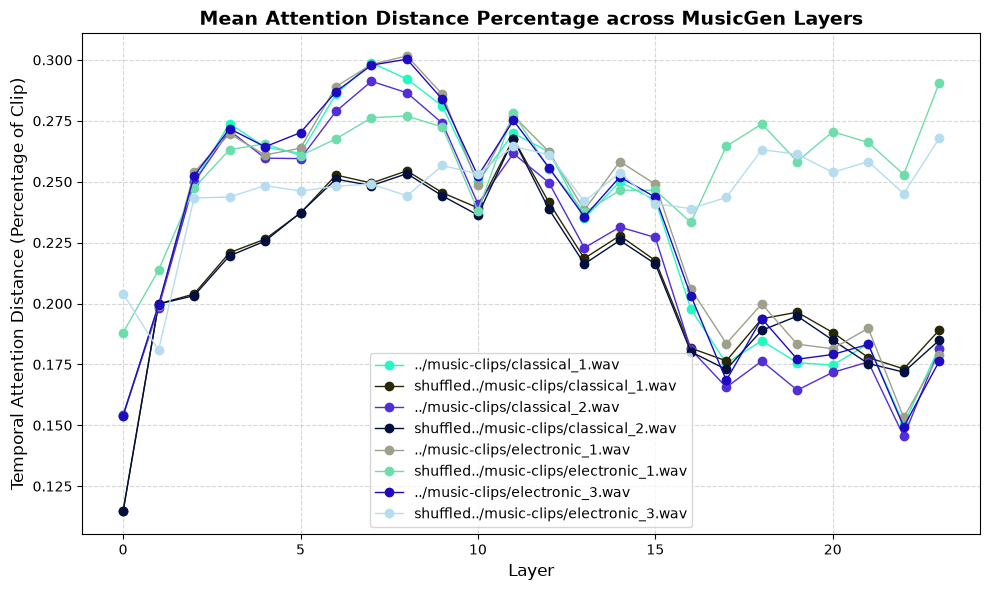

In [ ]:
plt.figure(figsize=(10, 6))

for path, mads in mad_dict_clean.items():
    random_hex = f"#{random.randint(0, 0xFFFFFF):06x}"
    num_layers = len(attentions_dict_clean.get(path))
    layer_averages_clean = np.mean(mads, axis=1)
    layer_averages_shuffled = np.mean(mad_dict_shuffled.get(path), axis=1)
    plt.plot(range(num_layers), layer_averages_clean, color=random_hex, linewidth=1, marker='o', label=path)
    plt.plot(range(num_layers), layer_averages_shuffled, color=f"#{random.randint(0, 0xFFFFFF):06x}", linewidth=1, marker='o', label='shuffled' + path)

plt.title("Mean Attention Distance Percentage across MusicGen Layers", fontsize=14, fontweight='bold')
plt.xlabel("Layer", fontsize=12)
plt.ylabel("Temporal Attention Distance (Percentage of Clip)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()